# LeetCode #210: Course Schedule II

https://leetcode.com/problems/course-schedule-ii/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **DFS with Post-order** | $O(V + E)$ | $O(V + E)$ |
| **BFS (Kahn's Algorithm)** | $O(V + E)$ | $O(V + E)$ |

---

## Understanding the Methods

### DFS with Post-order
Run DFS and add nodes to the result in post-order (after visiting all descendants). Reverse the result at the end. Detect cycles using a "visiting" state. If a cycle exists, return empty.

### BFS (Kahn's Algorithm) ★
Same as Course Schedule (#207) but record the processing order:
1. Build adjacency list and compute in-degrees.
2. Enqueue all nodes with in-degree 0.
3. Dequeue a node, add it to the result, decrement neighbors' in-degrees. Enqueue any neighbor that reaches 0.
4. If the result has all `numCourses` nodes, return it. Otherwise return empty (cycle exists).

**Why BFS is intuitive here:** The order in which nodes are dequeued is a valid topological order — each node is processed only after all its prerequisites.

**Constraints:**
* `1 <= numCourses <= 2000`
* `0 <= prerequisites.length <= numCourses * (numCourses - 1)`

## Solutions

### C#

In [ ]:
public class Solution {
    public int[] FindOrder(int numCourses, int[][] prerequisites) {
        var adj = new List<int>[numCourses];
        int[] inDegree = new int[numCourses];
        
        for (int i = 0; i < numCourses; i++) adj[i] = new List<int>();
        
        foreach (var p in prerequisites) {
            adj[p[1]].Add(p[0]);
            inDegree[p[0]]++;
        }
        
        var queue = new Queue<int>();
        for (int i = 0; i < numCourses; i++) {
            if (inDegree[i] == 0) queue.Enqueue(i);
        }
        
        var order = new List<int>();
        while (queue.Count > 0) {
            int node = queue.Dequeue();
            order.Add(node);
            foreach (int neighbor in adj[node]) {
                if (--inDegree[neighbor] == 0) queue.Enqueue(neighbor);
            }
        }
        
        return order.Count == numCourses ? order.ToArray() : new int[0];
    }
}

### Python

In [ ]:
from collections import deque, defaultdict

class Solution:
    def findOrder(self, numCourses: int, prerequisites: list[list[int]]) -> list[int]:
        adj = defaultdict(list)
        in_degree = [0] * numCourses
        
        for course, prereq in prerequisites:
            adj[prereq].append(course)
            in_degree[course] += 1
        
        queue = deque(i for i in range(numCourses) if in_degree[i] == 0)
        order = []
        
        while queue:
            node = queue.popleft()
            order.append(node)
            for neighbor in adj[node]:
                in_degree[neighbor] -= 1
                if in_degree[neighbor] == 0:
                    queue.append(neighbor)
        
        return order if len(order) == numCourses else []

### Go

In [ ]:
func findOrder(numCourses int, prerequisites [][]int) []int {
    adj := make([][]int, numCourses)
    inDegree := make([]int, numCourses)
    
    for _, p := range prerequisites {
        adj[p[1]] = append(adj[p[1]], p[0])
        inDegree[p[0]]++
    }
    
    queue := []int{}
    for i := 0; i < numCourses; i++ {
        if inDegree[i] == 0 {
            queue = append(queue, i)
        }
    }
    
    order := []int{}
    for len(queue) > 0 {
        node := queue[0]
        queue = queue[1:]
        order = append(order, node)
        for _, neighbor := range adj[node] {
            inDegree[neighbor]--
            if inDegree[neighbor] == 0 {
                queue = append(queue, neighbor)
            }
        }
    }
    
    if len(order) == numCourses {
        return order
    }
    return []int{}
}

### Rust

In [ ]:
use std::collections::VecDeque;

impl Solution {
    pub fn find_order(num_courses: i32, prerequisites: Vec<Vec<i32>>) -> Vec<i32> {
        let n = num_courses as usize;
        let mut adj = vec![vec![]; n];
        let mut in_degree = vec![0i32; n];
        
        for p in &prerequisites {
            adj[p[1] as usize].push(p[0] as usize);
            in_degree[p[0] as usize] += 1;
        }
        
        let mut queue: VecDeque<usize> = (0..n)
            .filter(|&i| in_degree[i] == 0)
            .collect();
        
        let mut order = Vec::new();
        while let Some(node) = queue.pop_front() {
            order.push(node as i32);
            for &neighbor in &adj[node] {
                in_degree[neighbor] -= 1;
                if in_degree[neighbor] == 0 {
                    queue.push_back(neighbor);
                }
            }
        }
        
        if order.len() == n { order } else { vec![] }
    }
}

## Example Scenarios

### 1. Common Case — Linear Chain
**Input:** `numCourses = 4, prerequisites = [[1,0],[2,1],[3,2]]`

A simple chain 0 → 1 → 2 → 3. Course 0 has in-degree 0, so it starts the queue. Each dequeue reveals exactly one new zero-in-degree node, producing [0,1,2,3].

WHY it's tricky: It isn't — validates that BFS topo-sort works on a straight dependency chain.

$V = 4,\ E = 3 \Rightarrow O(V+E) = O(7)$

### 2. Slightly Complex — Diamond DAG with Multiple Valid Orders
**Input:** `numCourses = 6, prerequisites = [[2,0],[3,0],[4,1],[4,2],[5,3],[5,4]]`

Nodes 0 and 1 both have in-degree 0. Paths merge at node 4 (needs both 1 and 2) and node 5 (needs both 3 and 4). Multiple valid topological orderings exist; BFS yields one deterministically.

WHY it's tricky: Two sources create a diamond. Node 4's in-degree only reaches 0 after *both* predecessors are processed — tests multi-parent convergence.

$V = 6,\ E = 6 \Rightarrow O(V+E) = O(12)$

### 3. Edge Case: Time Factor — Dense Graph (Near-Maximum Edges)
**Input:** `numCourses = 2000, prerequisites: course i depends on every j < i` → total edges = $2000 \times 1999 / 2 = 1{,}999{,}000$

A complete DAG. Only course 0 starts in the queue; each dequeue of course k reduces in-degrees of k+1 through 1999. Unique valid order: [0,1,...,1999].

WHY it's tricky: $E \approx n(n-1)/2 \approx 2 \times 10^6$. BFS processes each edge once, but adjacency list construction and in-degree updates dominate runtime.

$V = 2000,\ E = 1{,}999{,}000 \Rightarrow O(V+E) \approx O(2 \times 10^6)$

### 4. Edge Case: Space Factor — All Independent Courses
**Input:** `numCourses = 2000, prerequisites = []`

No edges — every course has in-degree 0 and is enqueued immediately. The queue holds all 2000 nodes at once, maximizing BFS memory. Any permutation is valid.

WHY it's tricky: Queue peaks at $n = 2000$ entries. The adjacency list is empty, so space is dominated by the in-degree array and queue: $O(V)$.

$\text{Queue size} = V = 2000$

### 5. Almost-Impossible — Large Cycle Blocks Everything
**Input:** `numCourses = 2000, prerequisites: 0→1→2→...→1999→0` (Hamiltonian cycle)

Every node has in-degree 1. The queue starts empty because no node has in-degree 0. BFS terminates immediately with an empty result.

WHY it's tricky: $V = E = 2000$. Cycle detection is immediate (empty initial queue), but verifies the algorithm correctly returns `[]` rather than a partial order.

$\text{Processed} = 0 \neq V \Rightarrow \text{return } []$


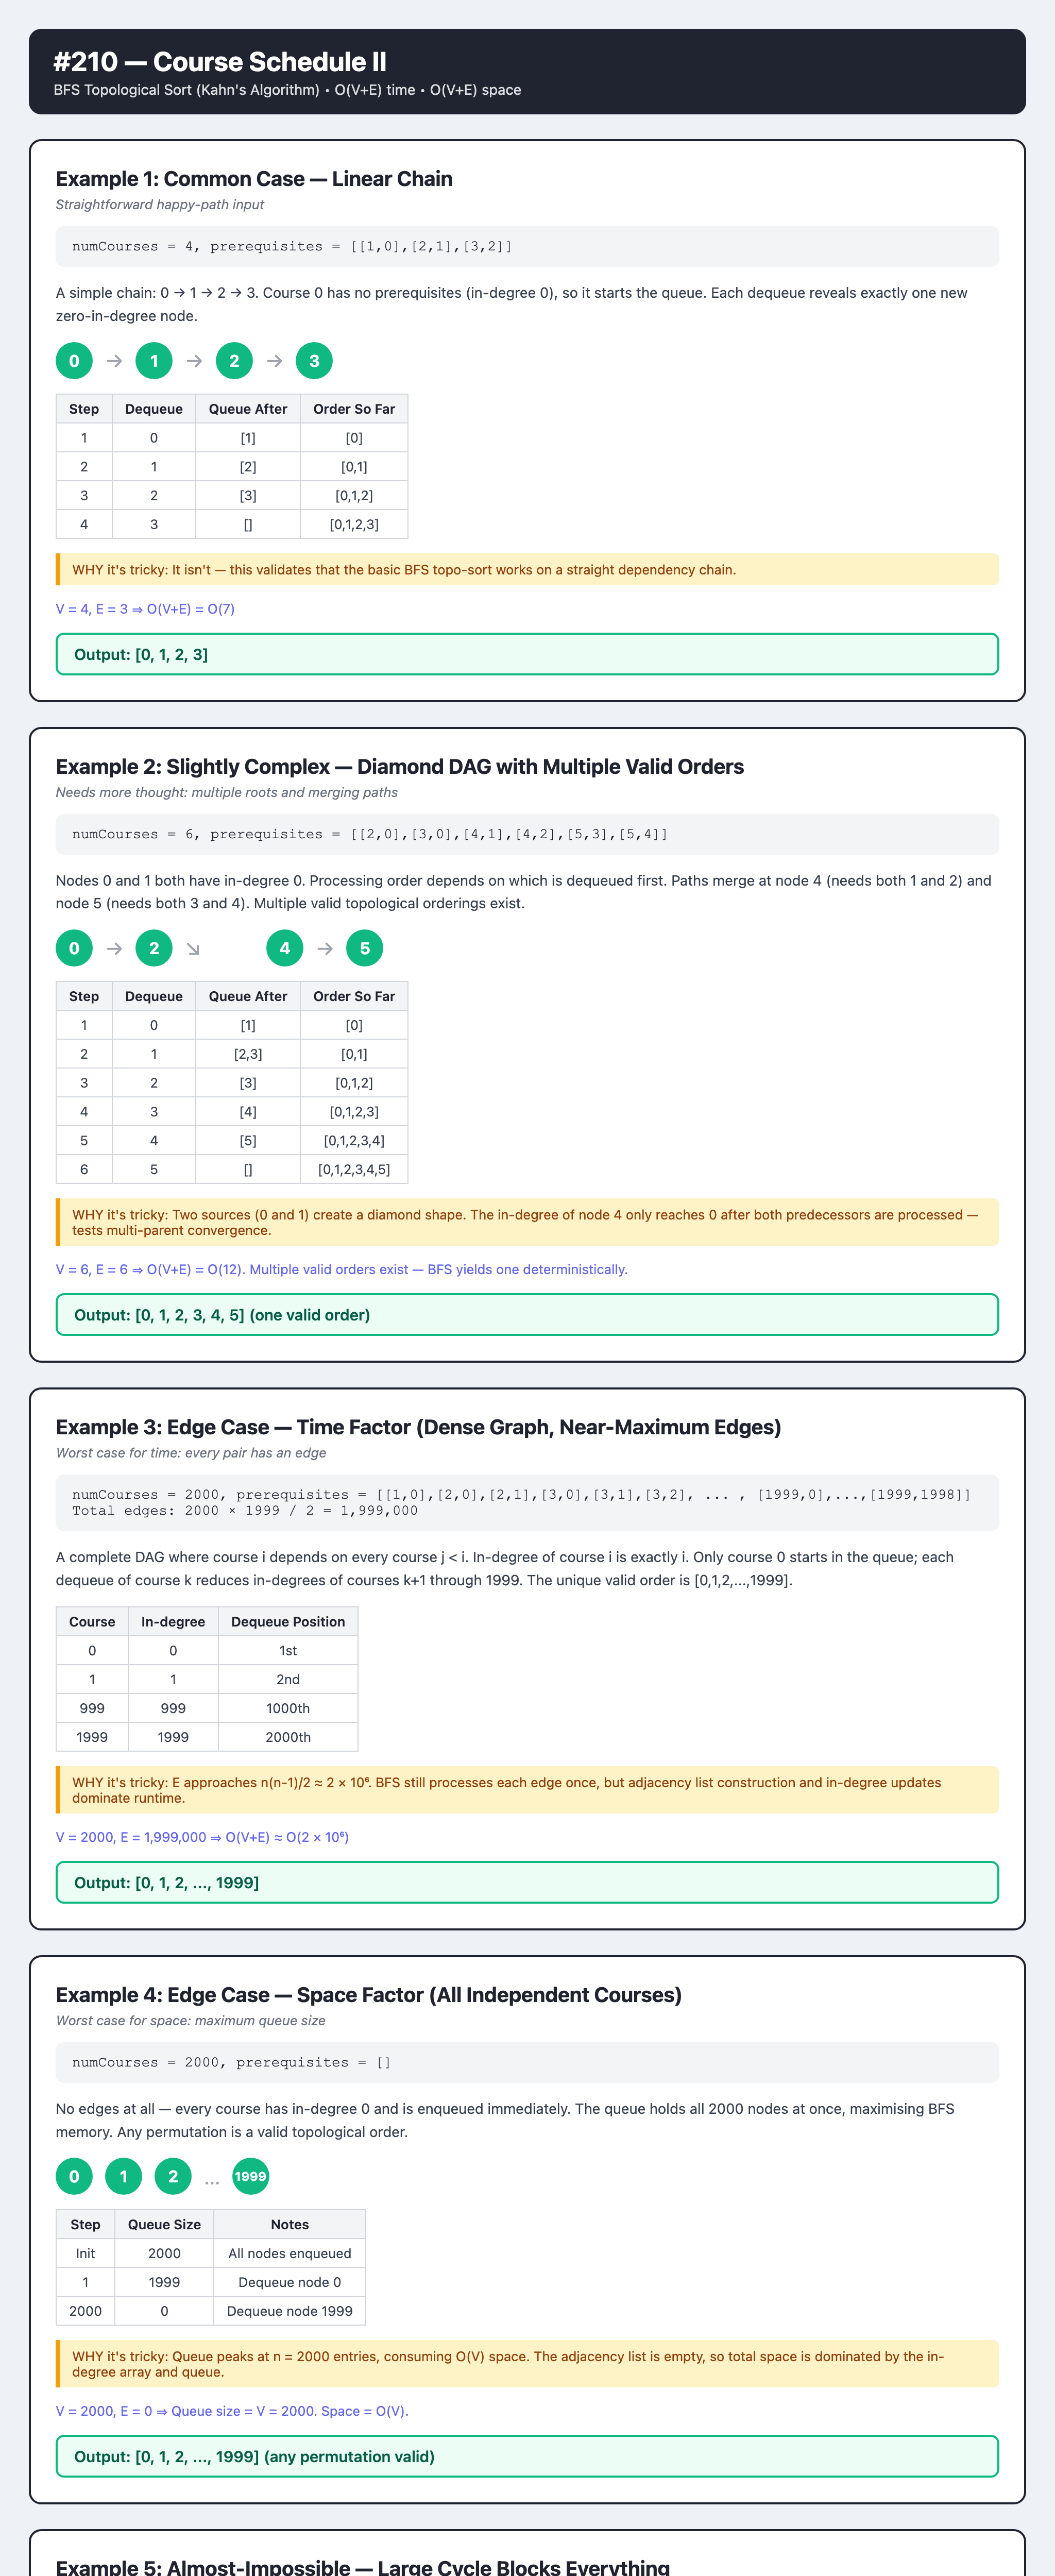